In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e


In [2]:
from pairinteraction.visualization.colormaps import alphamagma
import os
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 0, 0
l1_1, l2_1 = 1, 1
j1_0, j2_0 = 1/2, 1/2



if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()  

energy_unit = 'MHz'
    

In [19]:
n_dif=3
ldif=3
jdif=3
def get_system_pair_list_r(
    ket1: pi.SystemAtom, ket2: pi.SystemAtom, rs: np.ndarray, erange, angle, b, e
) -> list[pi.SystemPair]:
    
    basis1 = pi.BasisAtom(ket1.species, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))

    basis2 = pi.BasisAtom(ket2.species, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif, ket2.j+jdif))

    pair_systems = []
    for i, r in enumerate(rs):
        system1, system2 = pi.SystemAtom(basis1).set_magnetic_field([0,0,b], unit='G').set_electric_field([0,0,e], unit='V/cm'), pi.SystemAtom(basis2).set_magnetic_field([0,0,b], unit='G').set_electric_field([0,0,e], unit='V/cm')

        pi.diagonalize([system1, system2])
        pair_energy = system1.get_corresponding_energy(ket1, unit=energy_unit) + system2.get_corresponding_energy(ket2, unit=energy_unit)
        # print(f'pair energy = {pair_energy}{energy_unit}')
        min_energy, max_energy = pair_energy - erange, pair_energy + erange
        
        pair_basis = pi.BasisPair(
            [system1, system2], energy=(min_energy, max_energy), energy_unit=energy_unit
        )
        pair_systems.append(
            pi.SystemPair(pair_basis)
            .set_distance(r, unit='um', angle_degree=angle)
            )
        states_num = pair_basis.number_of_states
        # print(f"Number of two-atom basis states: {pair_basis.number_of_states}")


    # Diagonalize the systems in parallel
    pi.diagonalize(
        pair_systems,
        diagonalizer="eigen",
        energy_range=(min_energy, max_energy),
        energy_range_unit=energy_unit,
    )

    return pair_systems, states_num


In [13]:
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)

    n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  n2_1  l2_1  j2_1  \
0     45     0   0.5    47     0   0.5    45     1   1.5    46     1   1.5   
1     46     0   0.5    48     0   0.5    46     1   1.5    47     1   1.5   
2     48     0   0.5    51     0   0.5    48     1   1.5    50     1   0.5   
3     59     0   0.5    57     0   0.5    58     1   0.5    57     1   0.5   
4     61     0   0.5    65     0   0.5    61     1   0.5    64     1   0.5   
5     68     0   0.5    67     0   0.5    67     1   0.5    67     1   1.5   
6     69     0   0.5    68     0   0.5    68     1   0.5    68     1   1.5   
7     71     0   0.5    69     0   0.5    70     1   1.5    69     1   0.5   
8     72     0   0.5    70     0   0.5    71     1   1.5    70     1   0.5   
9     72     0   0.5    75     0   0.5    72     1   0.5    74     1   1.5   
10    73     0   0.5    76     0   0.5    73     1   0.5    75     1   1.5   
11    77     0   0.5    81     0   0.5    77     1   1.5    80  

In [14]:
channel = 3
c = channels.loc[channel]
# set atom properties
n1_0, l1_0, j1_0 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2_0, l2_0, j2_0 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 
mj1_0s, mj2_0s = np.arange(-j1_0, j1_0+1), np.arange(-j2_0, j2_0+1)
f1_0, f2_0 = 1, 1

n1_1, l1_1, j1_1 = int(c['n1_1']), int(c['l1_1']), c['j1_1']
n2_1, l2_1, j2_1 =  int(c['n2_1']), int(c['l2_1']), c['j2_1']
f1_1, f2_1 = 1, 1

btunes = np.unique(magTune_import(atom1, n1_0, l1_0, j1_0, atom2, n2_0, l2_0, j2_0, l1_1, l2_1))

ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=j1_0, j=j1_0)
ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=j2_0, j=j2_0)
ket1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=j1_1)
ket2_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=j2_1)
ket1_energy = ket1.get_energy(unit=energy_unit)
ket2_energy = ket2.get_energy(unit=energy_unit)

defect = c['defect']
ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=-j1_0), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=-j2_0)

bfield = 0  # Gauss
erange = abs(defect + defect*100)



In [17]:
rs = np.linspace(1, 20, 500)
e=0
bs = np.array([0])
bs = np.append(bs, np.array(btunes))
theta=0

In [20]:
system_pairs_dict: dict[float, list[pi.SystemPair]] = {}

system_pairs_dict_inter = {}
system_pairs_dict_Rb = {}
system_pairs_dict_Cs = {}

for b in bs:
    
    pairs = get_system_pair_list_r(ket1, ket2, rs, erange, theta, b, e)
    system_pairs = pairs[0]
    states_num = pairs[1]

    pairs_Rb = get_system_pair_list_r(ket1, ket1, rs, erange, theta, b, e)
    system_pairs_Rb = pairs_Rb[0]
    pairs_Cs = get_system_pair_list_r(ket2, ket2, rs, erange, theta, b, e)
    system_pairs_Cs = pairs_Cs[0]
    
    system_pairs_dict_inter.update({f'{b}{theta}': system_pairs})
    system_pairs_dict_Rb.update({f'{b}{theta}': system_pairs_Rb})
    system_pairs_dict_Cs.update({f'{b}{theta}': system_pairs_Cs})

print(system_pairs)

[SystemPair(BasisPair(|Rb:56,S_1/2,-1/2; Cs:60,S_1/2,-1/2⟩ ... |Rb:62,P_3/2,3/2; Cs:54,P_3/2,3/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,S_1/2,-1/2; Cs:60,S_1/2,-1/2⟩ ... |Rb:62,P_3/2,3/2; Cs:54,P_3/2,3/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,S_1/2,-1/2; Cs:60,S_1/2,-1/2⟩ ... |Rb:62,P_3/2,3/2; Cs:54,P_3/2,3/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,S_1/2,-1/2; Cs:60,S_1/2,-1/2⟩ ... |Rb:62,P_3/2,3/2; Cs:54,P_3/2,3/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,S_1/2,-1/2; Cs:60,S_1/2,-1/2⟩ ... |Rb:62,P_3/2,3/2; Cs:54,P_3/2,3/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,S_1/2,-1/2; Cs:60,S_1/2,-1/2⟩ ... |Rb:62,P_3/2,3/2; Cs:54,P_3/2,3/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,S_1/2,-1/2; Cs:60,S_1/2,-1/2⟩ ... |Rb:62,P_3/2,3/2; Cs:54,P_3/2,3/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,S_1/2,-1/2; Cs:60,S_1/2,-1/2⟩ ... |Rb:62,P_3/2,3/2; Cs:54,P_3/2,3/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,S_1/2,-1/2; Cs:60,S_1/2,-1/

In [ ]:
import os
datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations full\\inter intra\\'
if not os.path.exists(datapath + 'inter'):
    os.makedirs(datapath + 'inter')
if not os.path.exists(datapath + 'intra Rb'):
    os.makedirs(datapath + 'intra Rb')
if not os.path.exists(datapath + 'intra Cs'):
    os.makedirs(datapath + 'intra Cs')

pair_energy_inter = ket1_energy + ket2_energy
pair_energy_intra_Rb = ket1_energy + ket1_energy
pair_energy_intra_Cs = ket2_energy + ket2_energy
theta=0
energies_inter_dict = {f'{b}{theta}' : [system.get_eigenenergies(unit = energy_unit) - pair_energy_inter for system in system_pairs_dict_inter[f'{b}{theta}']] for b in bs}
energies_inter_dict.update({'rs' : rs})



energies_intra_Rb_dict = {f'{b}{theta}' : [system_Rb.get_eigenenergies(unit = energy_unit) - pair_energy_intra_Rb for system_Rb in system_pairs_dict_Rb[f'{b}{theta}']] for b in bs}
energies_intra_Rb_dict.update({'rs' : rs})

energies_intra_Cs_dict = {f'{b}{theta}' : [system_Cs.get_eigenenergies(unit = energy_unit) - pair_energy_intra_Cs for system_Cs in system_pairs_dict_Cs[f'{b}{theta}']] for b in bs}
energies_intra_Cs_dict.update({'rs' : rs})
    

In [ ]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations full\\inter intra\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']

# system_atom = system_atom_dict[efield]

system_pairs = system_pairs

b=0.0

for b in bs:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            import os
            if os.path.exists(datapath + f'inter\\mjs ({mj1}, {mj2}), b {np.round(b,3)}G, theta {theta}deg.csv'):
                overlapped_inter = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), b {np.round(b,3)}G, theta {theta}deg.csv')
                overlapped_intra_Rb = pd.read_csv(datapath + f'intra Rb\\mjs ({mj1}, {mj1}), b {np.round(b,3)}G, theta {theta}deg.csv')
                overlapped_intra_Cs = pd.read_csv(datapath + f'intra Cs\\mjs ({mj2}, {mj2}), b {np.round(b,3)}G, theta {theta}deg.csv')
            

            ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=mj1), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=mj2)

            system_pairs = system_pairs_dict_inter[f'{b}{theta}']
            system_pairs_Rb = system_pairs_dict_Rb[f'{b}{theta}']
            system_pairs_Cs = system_pairs_dict_Cs[f'{b}{theta}']

            overlaps_inter = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pairs]
            overlaps_intra_Rb = [system.get_eigenbasis().get_overlaps([ket1, ket1]) for system in system_pairs_Rb]
            overlaps_intra_Cs = [system.get_eigenbasis().get_overlaps([ket2, ket2]) for system in system_pairs_Cs]

            energies_inter = energies_inter_dict[f'{b}{theta}']
            energies_intra_Rb = energies_intra_Rb_dict[f'{b}{theta}']
            energies_intra_Cs = energies_intra_Cs_dict[f'{b}{theta}']

            
                    
            # 2. Build the RGBA array: (N, 4)
            # This stores the specific relevance for every point in THIS set
            
            
            # plt.axhline(defect, color='r', linewidth=2, alpha=1, linestyle='dotted')
            fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
            ax.set_xlabel("E_z (mV/cm)")
            ax.set_ylabel(f"Energy ({energy_unit})")
            ax.set_title(fr'separations $\mu$m')
            plt.tight_layout()
            plt.title(fr'{str(ket1)}{str(ket2)} angle = {theta}deg, b={np.round(b,2)}G, e={e}V/cm')
            energy_lim = abs(defect + defect*2)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            plt.ylim(min_energy, max_energy)
            # plt.xlim(2, 2.7)
            plt.ylabel(f"Energy [{energy_unit}]")
            plt.xlabel(r"Separation ($\mu$m)")
            # ax.plot(e_fields_sub, energies)

            # for x, es in zip(rs, energies_inter):
            #     plt.plot([x] * len(es), es, c='.7', ls="None", marker=".", ms=1, zorder=-1)
            r, energy, overlap = [], [], []
            min_overlap = 0.01
            for x, es, os in zip(rs, energies_inter, overlaps_inter):
                inds = np.argwhere(os > min_overlap).flatten()
                inds = inds[np.argsort(os[inds])]
                if len(inds) > 0:
                    r.extend([x] * len(es[inds]))
                    energy.extend(es[inds])
                    overlap.extend(os[inds])

                    rgba = np.zeros((len(es[inds]), 4))
                    base_rgb = mcolors.to_rgb(colours[0])
                    rgba[:, :3] = base_rgb
                    rgba[:, 3] = os[inds]

                    scat = plt.scatter(
                        [x] * len(es[inds]),
                        es[inds],
                        c=os[inds],
                        s=10,
                        vmin=0,
                        vmax=1,
                        marker='.',
                        cmap = 'Reds'
                    )
            overlapped_inter = {'r' : np.array(r), 'energy' : np.array(energy), 'overlap' : np.array(overlap)}
            fig.colorbar(scat, ax=ax, label=fr"$m_j$ = {ket1.m}, $m_j$ = {ket2.m}")

            r, energy, overlap = [], [], []
            for x, es, os in zip(rs, energies_intra_Rb, overlaps_intra_Rb):
                inds = np.argwhere(os > min_overlap).flatten()
                inds = inds[np.argsort(os[inds])]
                if len(inds) > 0:
                    r.extend([x] * len(es[inds]))
                    energy.extend(es[inds])
                    overlap.extend(os[inds])

                    rgba = np.zeros((len(es[inds]), 4))
                    base_rgb = mcolors.to_rgb(colours[1])
                    rgba[:, :3] = base_rgb
                    rgba[:, 3] = os[inds]
                    scat = plt.scatter(
                        [x] * len(es[inds]),
                        es[inds],
                        c=os[inds],
                        s=10,
                        vmin=0,
                        vmax=1,
                        marker='.',
                        cmap = 'Purples'
                    )
            overlapped_intra_Rb = {'r' : np.array(r), 'energy' : np.array(energy), 'overlap' : np.array(overlap)}
            
            r, energy, overlap = [], [], []
            for x, es, os in zip(rs, energies_intra_Cs, overlaps_intra_Cs):
                inds = np.argwhere(os > min_overlap).flatten()
                inds = inds[np.argsort(os[inds])]
                if len(inds) > 0:
                    r.extend([x] * len(es[inds]))
                    energy.extend(es[inds])
                    overlap.extend(os[inds])

                    rgba = np.zeros((len(es[inds]), 4))
                    base_rgb = mcolors.to_rgb(colours[2])
                    rgba[:, :3] = base_rgb
                    rgba[:, 3] = os[inds]
                    scat = plt.scatter(
                        [x] * len(es[inds]),
                        es[inds],
                        c=os[inds],
                        s=10,
                        vmin=0,
                        vmax=1,
                        marker='.',
                        cmap = 'Blues'
                    )


            overlapped_intra_Cs = {'r' : np.array(r), 'energy' : np.array(energy), 'overlap' : np.array(overlap)}
            pd.DataFrame(overlapped_inter).to_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), b {np.round(b,3)}G, theta {theta}deg.csv')
            pd.DataFrame(overlapped_intra_Rb).to_csv(datapath + f'intra Rb\\mjs ({mj1}, {mj1}), b {np.round(b,3)}G, theta {theta}deg.csv')
            pd.DataFrame(overlapped_intra_Cs).to_csv(datapath + f'intra Cs\\mjs ({mj2}, {mj2}), b {np.round(b,3)}G, theta {theta}deg.csv')
            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            fig.savefig(figpath + f'theta {theta} b{np.round(b,3)}G e{e}Vcm mjs{ket1.m},{ket2.m}.png')


NameError: name 'energies_inter_dict' is not defined

In [124]:
print(overlapped_intra_Cs)

{'r': array([ 1.45691383,  1.49498998,  1.53306613,  1.53306613,  1.53306613,
        1.53306613,  1.53306613,  1.57114228,  1.60921844,  1.64729459,
        1.68537074,  1.68537074,  1.72344689,  1.76152305,  1.7995992 ,
        1.83767535,  1.8757515 ,  1.91382766,  1.95190381,  1.98997996,
        2.02805611,  2.06613226,  2.10420842,  2.14228457,  2.18036072,
        2.21843687,  2.25651303,  2.25651303,  2.29458918,  2.29458918,
        2.33266533,  2.33266533,  2.37074148,  2.37074148,  2.40881764,
        2.40881764,  2.44689379,  2.44689379,  2.48496994,  2.48496994,
        2.52304609,  2.52304609,  2.56112224,  2.56112224,  2.5991984 ,
        2.5991984 ,  2.63727455,  2.63727455,  2.6753507 ,  2.6753507 ,
        2.71342685,  2.71342685,  2.75150301,  2.75150301,  2.78957916,
        2.78957916,  2.82765531,  2.82765531,  2.86573146,  2.86573146,
        2.90380762,  2.90380762,  2.94188377,  2.94188377,  2.97995992,
        2.97995992,  3.01803607,  3.01803607,  3.05611222,

{'r': array([ 1.15230461,  1.19038076,  1.22845691,  1.26653307,  1.30460922,
        1.34268537,  1.38076152,  1.41883768,  1.41883768,  1.45691383,
        1.45691383,  1.49498998,  1.49498998,  1.49498998,  1.53306613,
        1.53306613,  1.53306613,  1.57114228,  1.57114228,  1.57114228,
        1.60921844,  1.60921844,  1.60921844,  1.64729459,  1.64729459,
        1.64729459,  1.68537074,  1.68537074,  1.68537074,  1.68537074,
        1.72344689,  1.72344689,  1.72344689,  1.76152305,  1.76152305,
        1.76152305,  1.7995992 ,  1.7995992 ,  1.7995992 ,  1.83767535,
        1.83767535,  1.83767535,  1.8757515 ,  1.8757515 ,  1.8757515 ,
        1.91382766,  1.91382766,  1.91382766,  1.95190381,  1.95190381,
        1.95190381,  1.95190381,  1.98997996,  1.98997996,  1.98997996,
        1.98997996,  2.02805611,  2.02805611,  2.02805611,  2.02805611,
        2.06613226,  2.06613226,  2.06613226,  2.06613226,  2.10420842,
        2.10420842,  2.10420842,  2.10420842,  2.14228457,

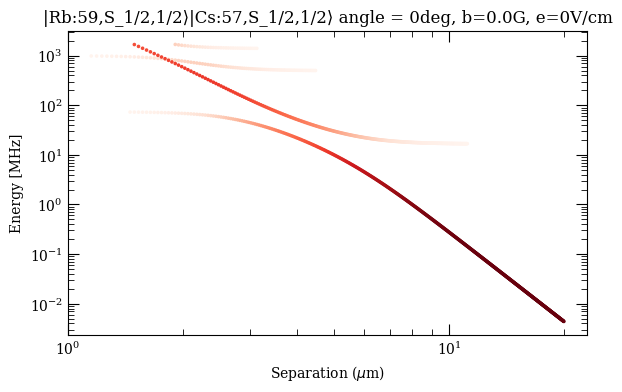

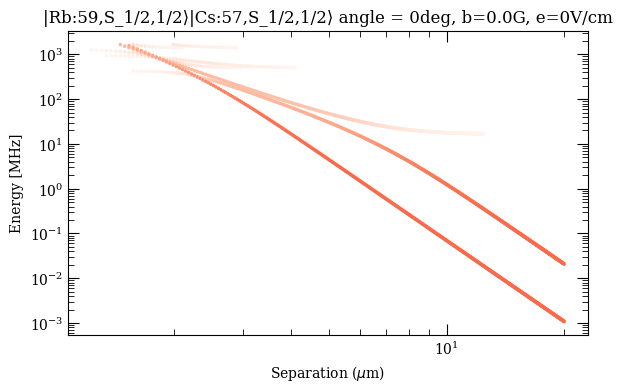

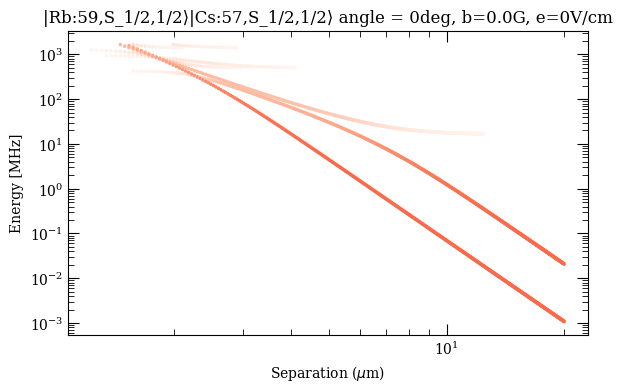

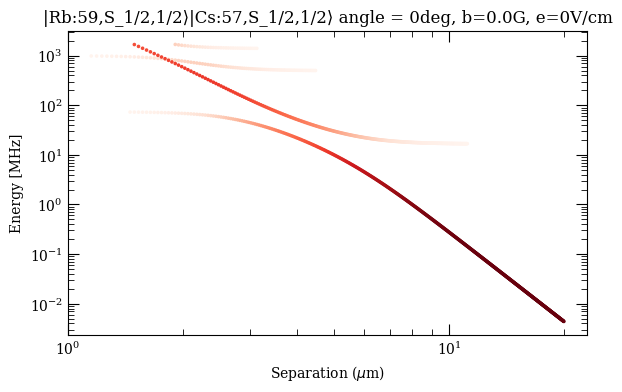

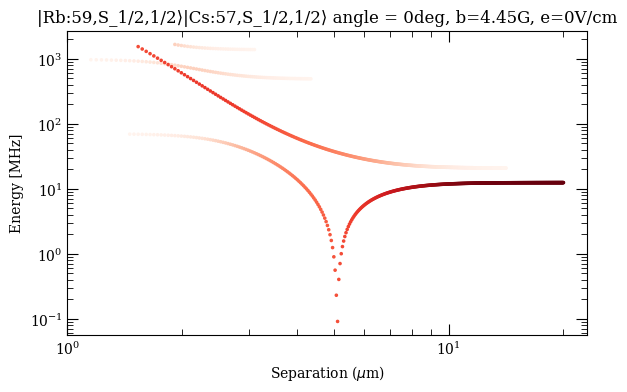

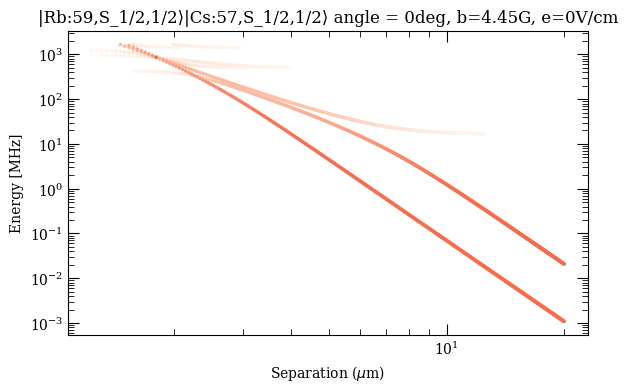

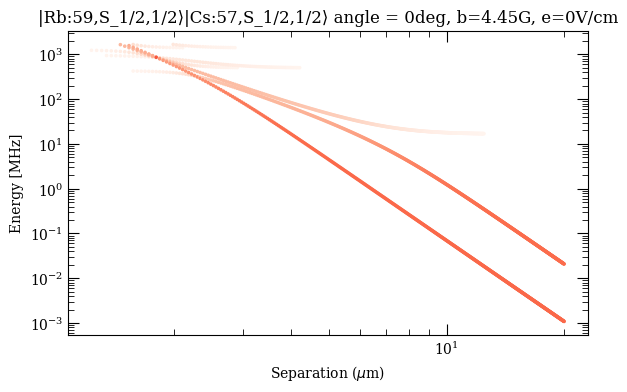

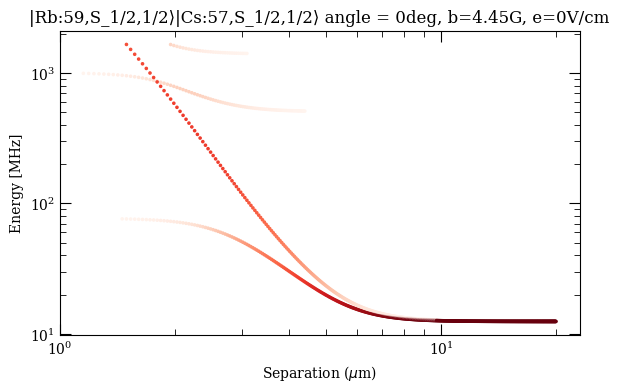

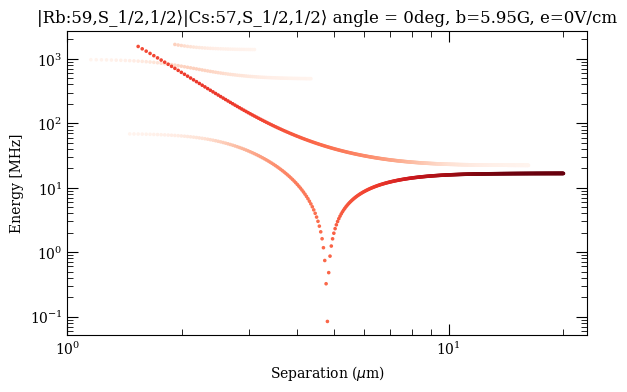

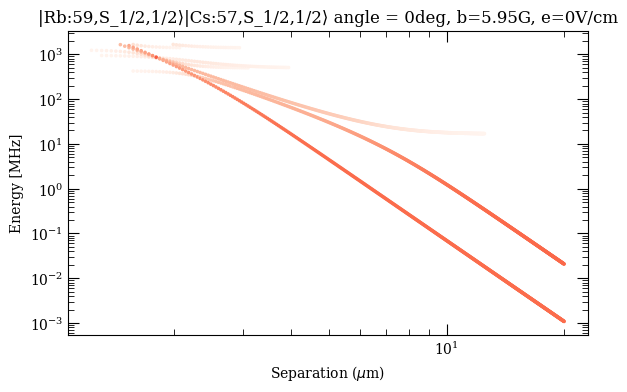

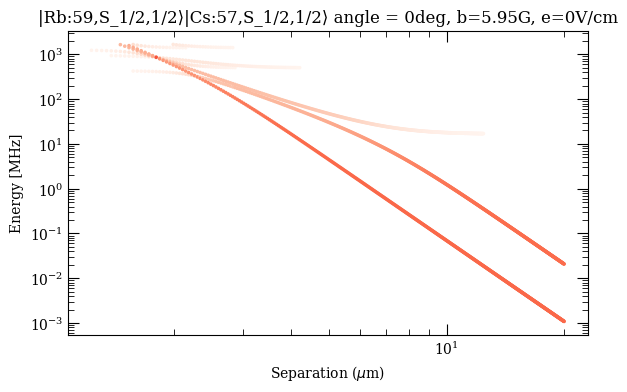

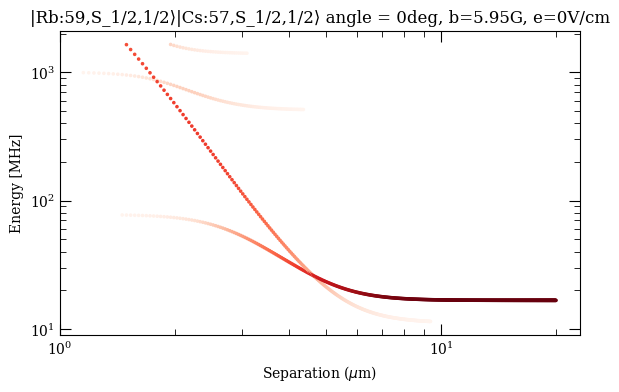

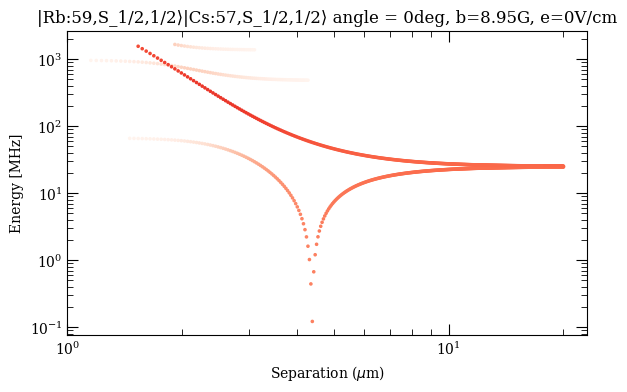

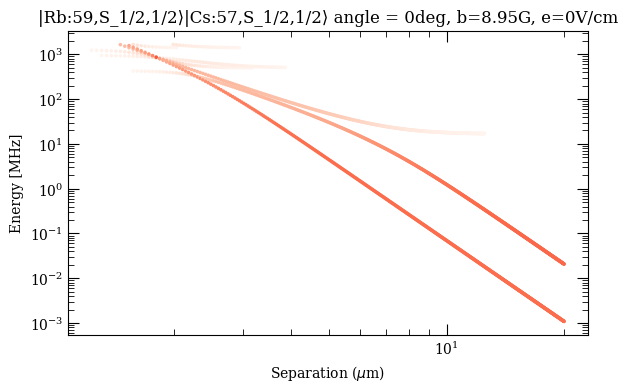

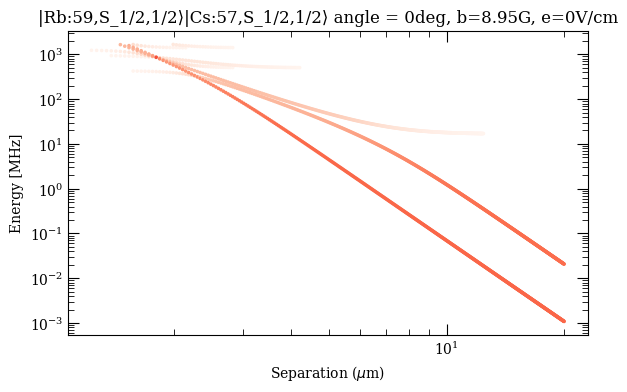

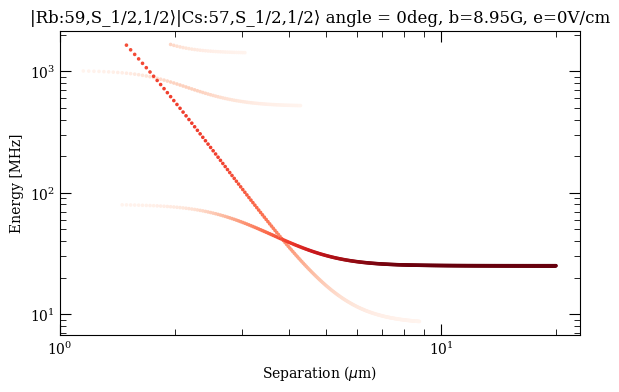

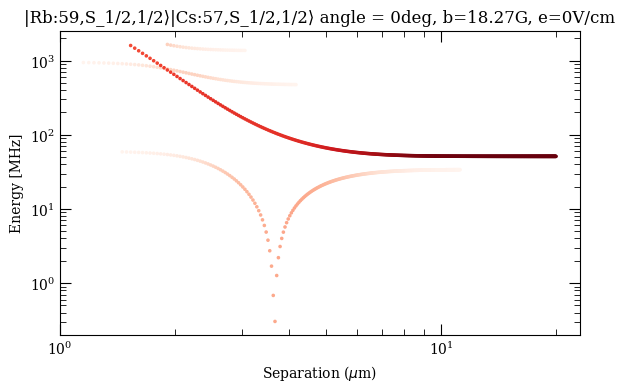

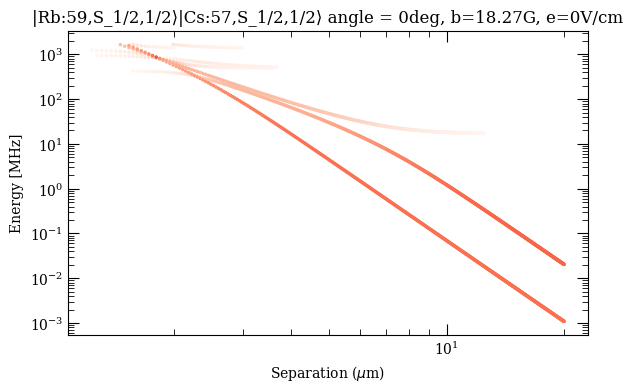

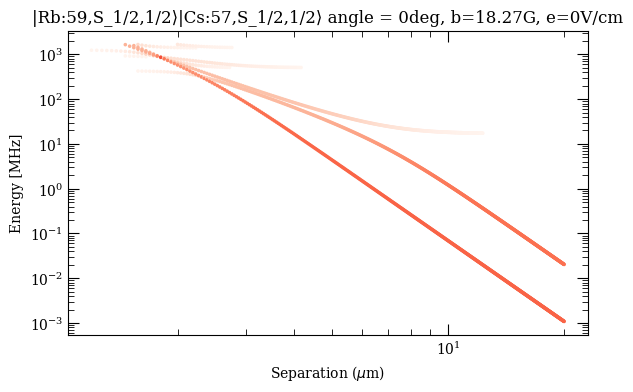

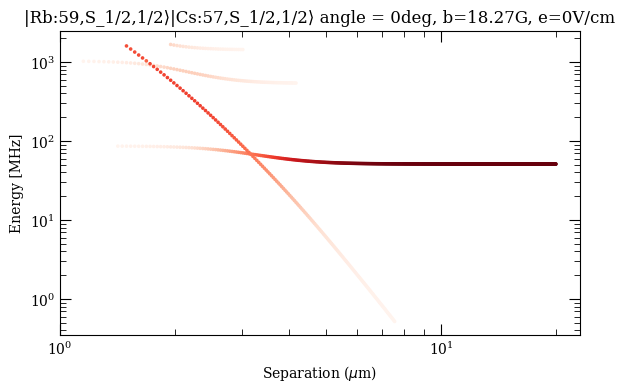

In [ ]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\log\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)
# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']

# system_atom = system_atom_dict[efield]

system_pairs = system_pairs

b=0.0
for b in bs:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            print(overlapped_inter)
            overlapped = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), b {np.round(b,3)}G, theta {theta}deg.csv')

            print(overlapped_intra_Cs['r'][0])
            j=0
            rBig = overlapped_intra_Cs['r'][0]
            corrected = {'energy' : [], 'r' : [], 'overlap' : []}
            
            r = overlapped_inter['r'][0]
            for i, rCs in enumerate(overlapped_intra_Cs['r']):
                if rCs < r:
                    continue
                while r <= rCs:
                    print(j)
                    if j >= len(overlapped_inter['r']):
                        break
                    r = overlapped_inter['r'][j]
                    if r == rCs:
                                       
                        corrected['energy'].append(overlapped['energy'][j] - overlapped['energy'][-1])
                        corrected['r'].append(r)
                        corrected['overlap'].append(overlapped_inter['overlap'][j])
                    j += 1

            fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
            ax.set_xlabel("E_z (mV/cm)")
            ax.set_ylabel(f"Energy ({energy_unit})")
            ax.set_title(fr'separations $\mu$m')
            ax.set_yscale('log')
            ax.set_xscale('log')
            plt.tight_layout()
            plt.title(fr'{str(ket1)}{str(ket2)} angle = {theta}deg, b={np.round(b,2)}G, e={e}V/cm')
            energy_lim = abs(defect + defect*2)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            # plt.ylim(min_energy, max_energy)
            # plt.xlim(2, 2.7)
            plt.ylabel(f"Energy [{energy_unit}]")
            plt.xlabel(r"Separation ($\mu$m)")
            # ax.plot(e_fields_sub, energies)

            # for x, es in zip(rs, energies_inter):
            #     plt.plot([x] * len(es), es, c='.7', ls="None", marker=".", ms=1, zorder=-1)
            min_overlap = 0.01
            

            scat = plt.scatter(
                corrected['r'],
                abs(overlapped_inter['energy']),
                c=overlapped_inter['overlap'],
                s=10,
                vmin=0,
                vmax=1,
                marker='.',
                cmap = 'Reds'
            )

            # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            fig.savefig(figpath + f'theta {theta} b{np.round(b,3)}G e{e}Vcm mjs{ket1.m},{ket2.m}.png')


1.4569138276553106
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272

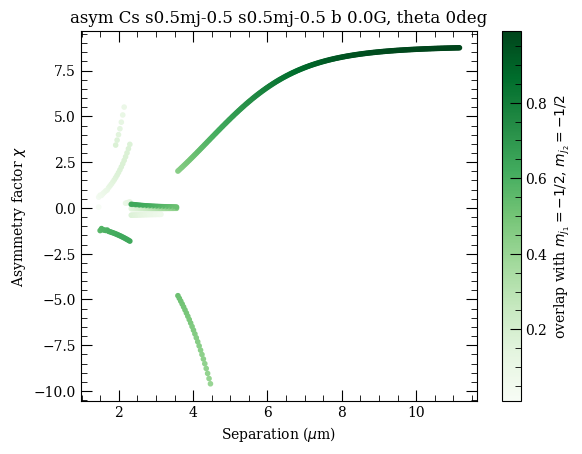

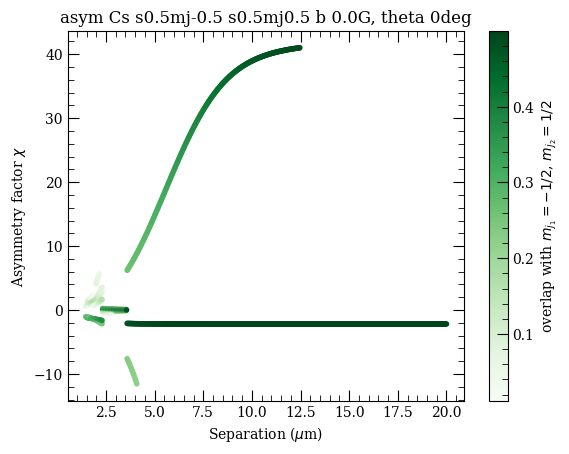

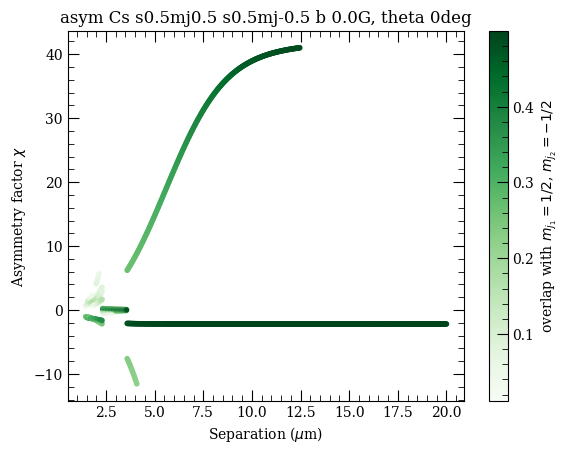

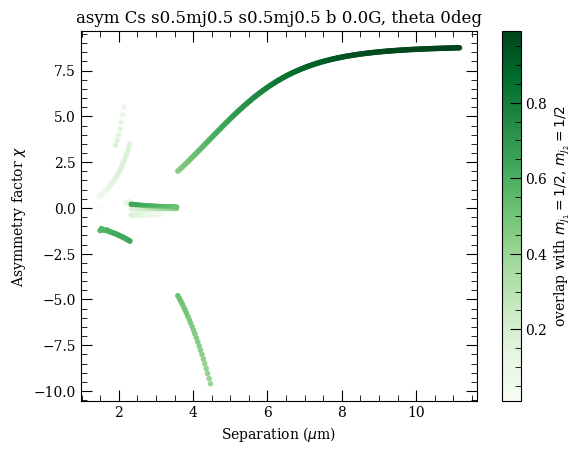

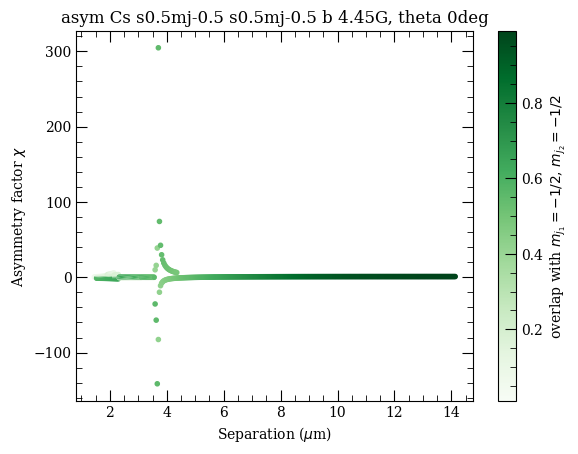

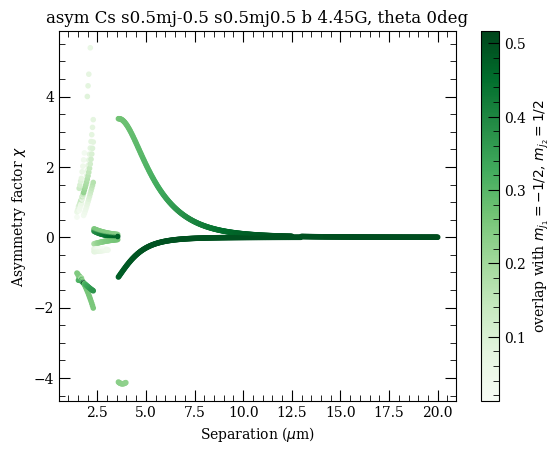

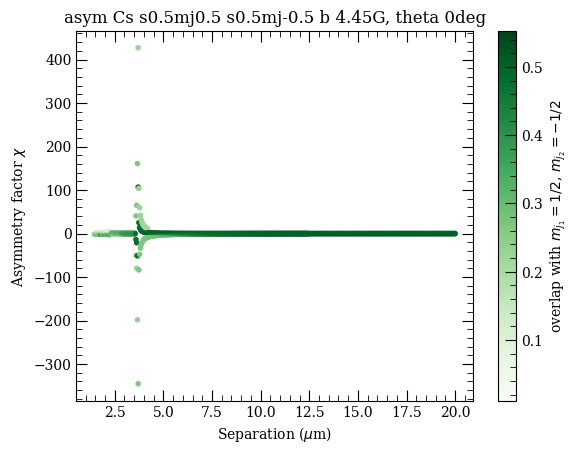

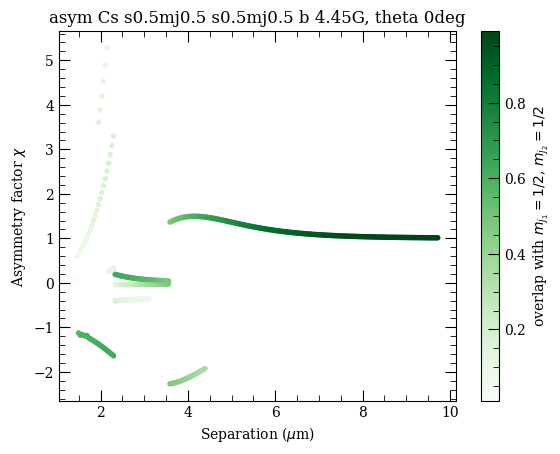

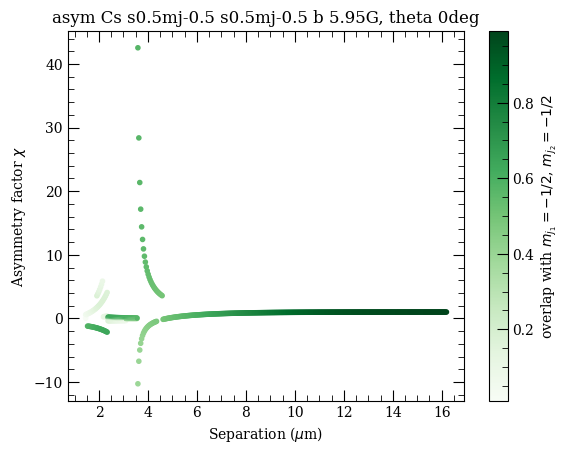

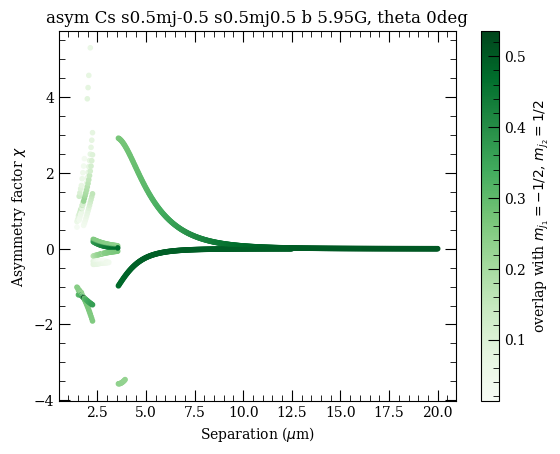

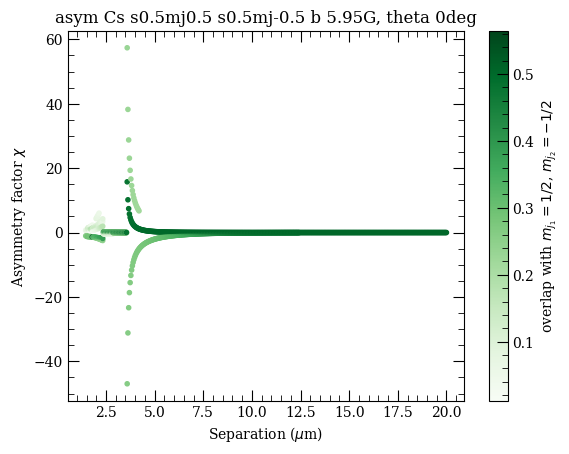

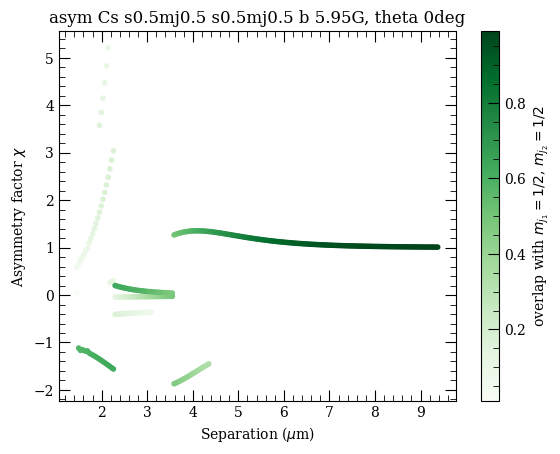

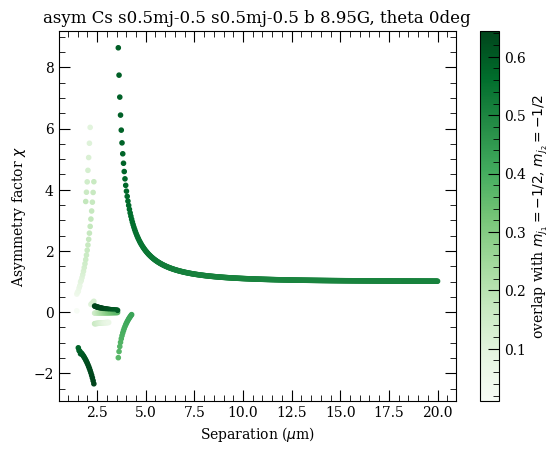

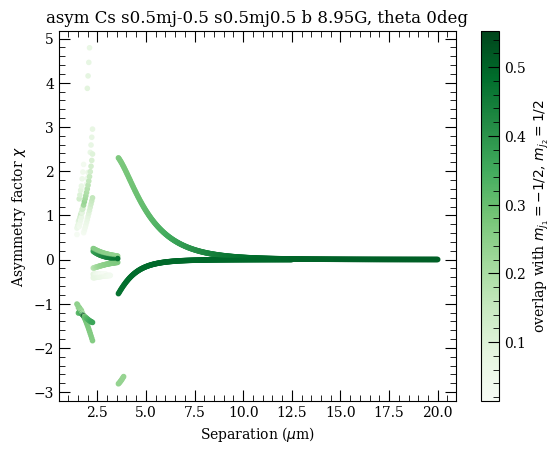

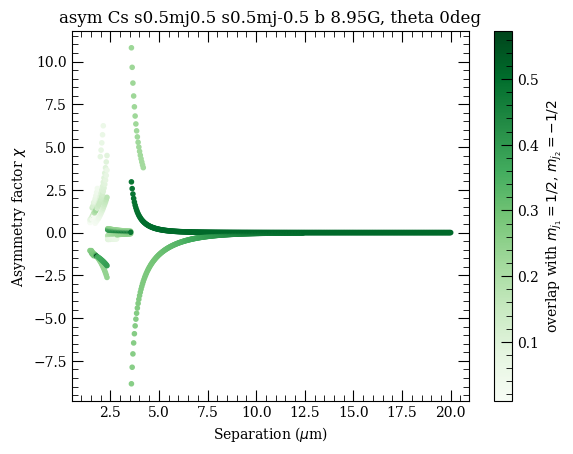

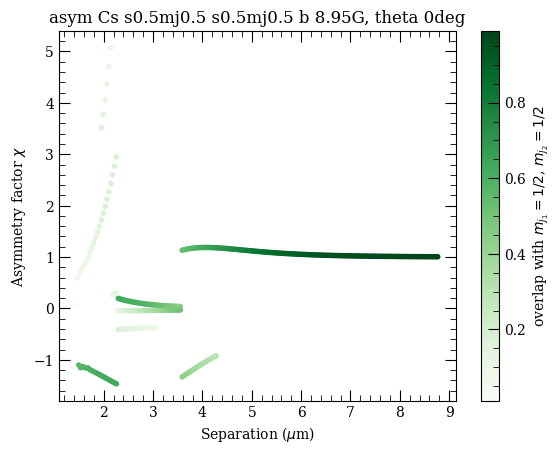

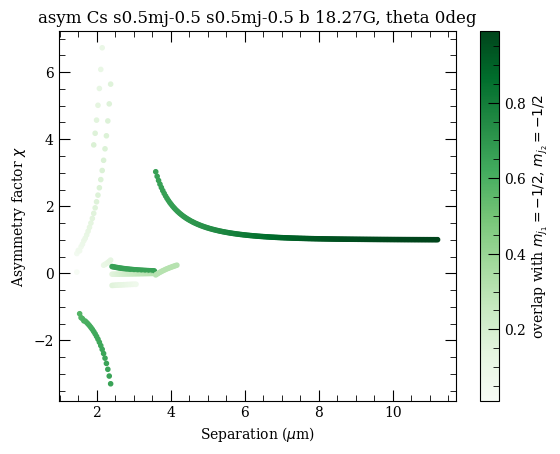

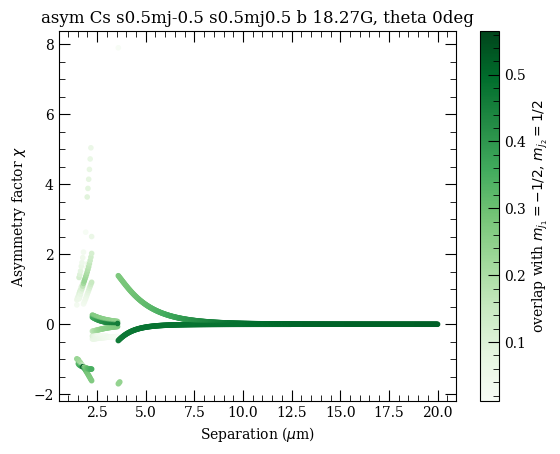

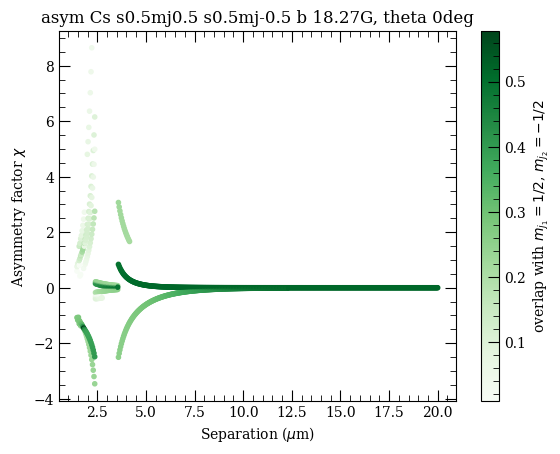

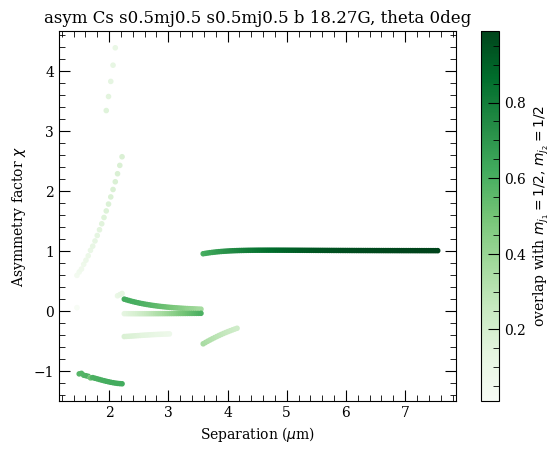

In [22]:
import os
datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations full\\inter intra\\'

figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\asymmetry\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)
# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']

# system_atom = system_atom_dict[efield]


b=0.0
for b in bs:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            overlapped_inter = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), b {np.round(b,3)}G, theta {theta}deg.csv')
            overlapped_intra_Rb = pd.read_csv(datapath + f'intra Rb\\mjs ({mj1}, {mj1}), b {np.round(b,3)}G, theta {theta}deg.csv')
            overlapped_intra_Cs = pd.read_csv(datapath + f'intra Cs\\mjs ({mj2}, {mj2}), b {np.round(b,3)}G, theta {theta}deg.csv')
            print(overlapped_intra_Cs['r'][0])
            j=0
            rCs = overlapped_intra_Cs['r'][0]
            assym_Cs = {'chi' : [], 'r' : [], 'overlap' : []}
            
            r = overlapped_inter['r'][0]
            for i, rCs in enumerate(overlapped_intra_Cs['r']):
                if rCs < r:
                    continue
                while r <= rCs:
                    print(j)
                    if j >= len(overlapped_inter['r']):
                        break
                    r = overlapped_inter['r'][j]
                    if r == rCs:
                                       
                        assym_Cs['chi'].append(overlapped_inter['energy'][j]/overlapped_intra_Cs['energy'][i])
                        assym_Cs['r'].append(r)
                        assym_Cs['overlap'].append(overlapped_inter['overlap'][j])
                    j += 1
                    
            print(assym_Cs)

            fig = plt.figure()
            plt.scatter(assym_Cs['r'], assym_Cs['chi'], c=assym_Cs['overlap'], cmap='Greens', marker= '.')
            plt.colorbar(label = fr'overlap with $m_{{j_1}} = {int(2*mj1)}/2$, $m_{{j_2}} = {int(2*mj2)}/2$')
            plt.xlabel(r'Separation ($\mu$m)')
            plt.ylabel(r'Asymmetry factor $\chi$')
            plt.title(f'asym Cs {orbs[l1_0]}{j1_0}mj{mj1} {orbs[l2_0]}{j2_0}mj{mj2} b {np.round(b,2)}G, theta {theta}deg')
            fig.savefig(figpath + f'mjs {mj1}{mj2}, theta {theta} b{np.round(b,3)}G e{e}Vcm mjs{ket1.m},{ket2.m}.png')


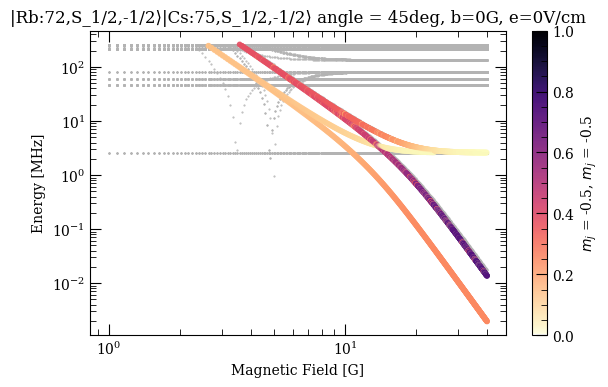

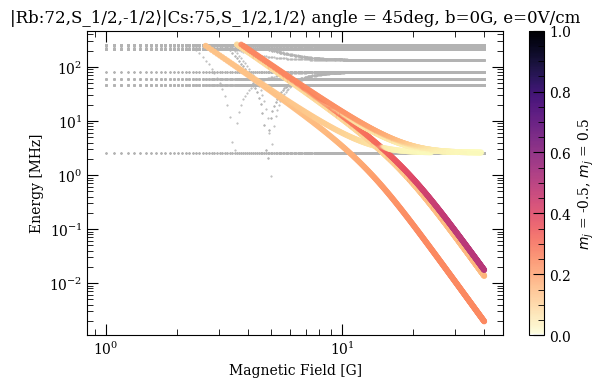

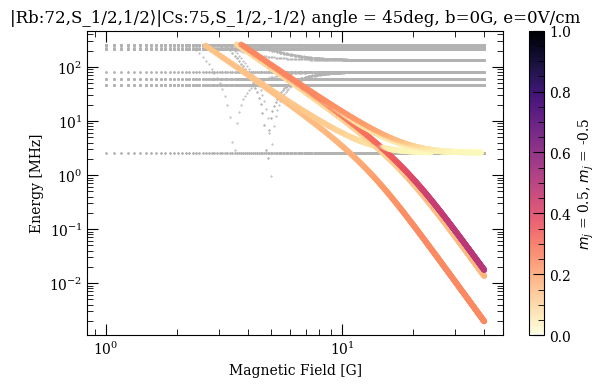

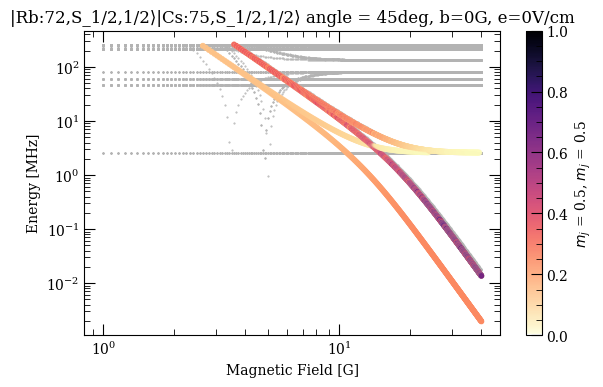

In [9]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\separations\\overlapped\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\to {orbs[l1_1]}{orbs[l2_1]}\\j1j2({j1_0},{j2_0})\\log\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

for mj1 in mj1_0s:
    for mj2 in mj2_0s:

        ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=mj1), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=mj2)
        overlaps1 = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pairs]


        # plt.axhline(defect, color='r', linewidth=2, alpha=1, linestyle='dotted')
        fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_xlabel("E_z (mV/cm)")
        ax.set_ylabel(f"Energy ({energy_unit})")
        ax.set_title(fr'separations $\mu$m')
        plt.tight_layout()
        plt.title(fr'{str(ket1)}{str(ket2)} angle = {angle}deg, b={b}G, e={e}V/cm')
        energy_lim = abs(defect + defect*2)
        offset=defect/2
        min_energy = -energy_lim+offset
        max_energy = energy_lim+offset
        # plt.ylim(min_energy, max_energy)
        # plt.xlim(2, 2.7)
        plt.ylabel(f"Energy [{energy_unit}]")
        plt.xlabel("Magnetic Field [G]")
        # ax.plot(e_fields_sub, energies)

        for x, es in zip(rs, energies):
            plt.plot([x] * len(es), abs(es), c='.7', ls="None", marker=".", ms=1, zorder=-1)
        min_overlap = 0.000
        for x, es, os in zip(rs, energies, overlaps1):
            inds = np.argwhere(os > min_overlap).flatten()
            inds = inds[np.argsort(os[inds])]
            if len(inds) > 0:
                scat = plt.scatter(
                    [x] * len(es[inds]),
                    abs(es[inds]),
                    c=os[inds],
                    s=10,
                    vmin=0,
                    vmax=1,
                    cmap=alphamagma,
                )
        fig.colorbar(scat, ax=ax, label=fr"$m_j$ = {ket1.m}, $m_j$ = {ket2.m}")
        # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
        fig.savefig(figpath + f'level pairstate deg{angle} b{b}G e{e}Vcm mjs{ket1.m},{ket2.m}.png')


{'mjs0-0.5-0.5': [], 'mjs0-0.50.5': [], 'mjs00.5-0.5': [], 'mjs00.50.5': []}


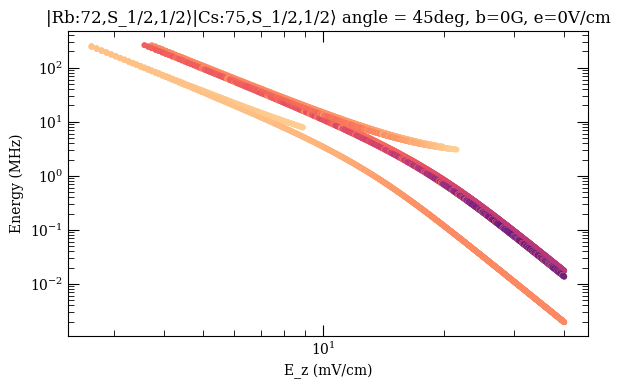

In [10]:
min_overlap = 0.1
energies_dict_0 = {f'mjs0{mj1_0}{mj2_0}': [] for mj1_0 in mj1_0s for mj2_0 in mj2_0s}
print(energies_dict_0)
fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel("E_z (mV/cm)")
ax.set_ylabel(f"Energy ({energy_unit})")
ax.set_title(fr'separations $\mu$m')
plt.tight_layout()
plt.title(fr'{str(ket1)}{str(ket2)} angle = {angle}deg, b={b}G, e={e}V/cm')

for mj1_0 in mj1_0s:
    for mj2_0 in mj2_0s:
        ket1_0 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=mj1_0)
        ket2_0 = pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=mj2_0)
        overlaps1 = [system.get_eigenbasis().get_overlaps([ket1_0, ket2_0]) for system in system_pairs]

        energies1=[]
        ds=[]
        for x, es, os in zip(rs, energies, overlaps1):
            inds = np.argwhere(os > min_overlap).flatten()
            inds = inds[np.argsort(os[inds])]
            if len(inds) > 0:
                scat = plt.scatter(
                    [x] * len(es[inds]),
                    abs(es[inds]),
                    c=os[inds],
                    s=10,
                    vmin=0,
                    vmax=1,
                    cmap=alphamagma,
                )
                energies1 = np.append(energies1, es[inds])
                ds = np.append(ds, [x] * len(es[inds]))
        energies_dict_0[f'rs{mj1_0}{mj2_0}'] = ds
        energies_dict_0[f'mjs0{mj1_0}{mj2_0}'] = energies1

[ 2.64128257  2.64128257  2.71943888 ... 39.92184369 40.
 40.        ]
182 182
[[445056.6512226]]
[117.84927326]


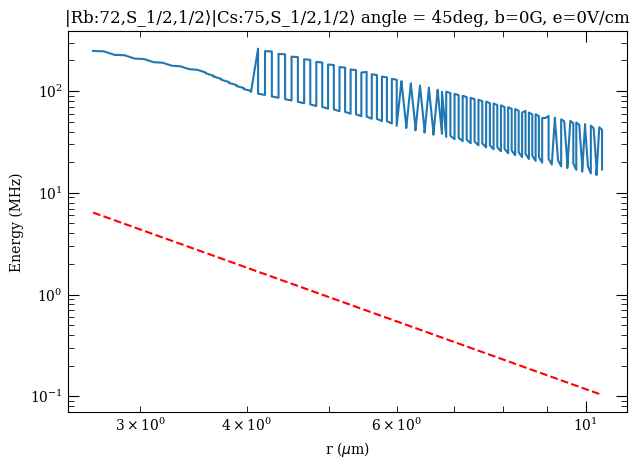

In [18]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\log fitted\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\log fitted\\'
if not os.path.exists(datapath):
    os.makedirs(datapath)

def func(r, c):
    return c/(r)**3 
rmax=10.5
mj1_0, mj2_0 = -1/2, -1/2
ds = energies_dict_0[f'rs{mj1_0}{mj2_0}']
print(ds)
ds = ds[np.argwhere(ds<rmax)].flatten()[::2]

energy = energies_dict_0[f'mjs0{mj1_0}{mj2_0}']
energy = energy[np.argwhere(ds<rmax)].flatten()
print(len(ds), len(energy))
popt, pcov = scipy.optimize.curve_fit(func, ds, energy)
fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r"r ($\mu$m)")
ax.set_ylabel(f"Energy ({energy_unit})")
ax.set_title(fr'separations $\mu$m')
plt.tight_layout()
plt.title(fr'{str(ket1)}{str(ket2)} angle = {angle}deg, b={b}G, e={e}V/cm')

ax.plot(ds, abs(energy))
ax.plot(ds, abs(func(ds, *popt)), linestyle='dashed', color='red')
fig.savefig(figpath + f'deg{angle} b{b}G e{e}Vcm mjs{mj1_0},{mj2_0}.png')
print(pcov)
C3 = pd.DataFrame({'c3' : [popt[0]], 'error' : [np.sqrt(np.diag(pcov))[0]]})
C3.to_csv(datapath + f'deg{angle} b{b}G e{e}Vcm mjs{mj1_0},{mj2_0}.csv', index=False)

print(popt)